# 放熱の基礎 II：単一薄板の2次元温度場

対応章: [`../chapters/02_stegosaurus_heat_shape.md`](../chapters/02_stegosaurus_heat_shape.md)

このNotebookでは長方形薄板を1種類だけ扱う。複数の背板形状の定義と比較は卒業研究として学生自身が実装する。

## 1. ライブラリと物理パラメータ

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.sparse import lil_matrix
from scipy.sparse.linalg import spsolve

k = 20.0          # thermal conductivity [W/(m K)]
h = 25.0          # convection coefficient [W/(m^2 K)]
T_base = 40.0     # root temperature [degC]
T_air = 25.0      # air temperature [degC]
height = 0.40     # plate height [m]
width = 0.18      # plate width [m]
thickness = 0.02  # plate thickness [m]

## 2. 長方形格子と定常熱伝導ソルバー

根元セルを $T_{base}$ に固定し、それ以外のセルで伝導と対流の熱収支を解く。

In [2]:
def solve_rectangular_plate(dx=0.005, h_value=h):
    x = np.arange(-width / 2, width / 2 + dx / 2, dx)
    y = np.arange(0.0, height + dx / 2, dx)
    nx, ny = len(x), len(y)
    index = np.arange(nx * ny).reshape(ny, nx)
    A = lil_matrix((nx * ny, nx * ny))
    b = np.zeros(nx * ny)
    g_cond = k * thickness
    g_face = 2.0 * h_value * dx**2
    g_edge = h_value * thickness * dx
    directions = [(-1, 0), (1, 0), (0, -1), (0, 1)]

    for iy in range(ny):
        for ix in range(nx):
            p = index[iy, ix]
            if iy == 0:
                A[p, p] = 1.0
                b[p] = T_base
                continue

            diagonal = g_face
            exposed_edges = 0
            for diy, dix in directions:
                jy, jx = iy + diy, ix + dix
                if 0 <= jy < ny and 0 <= jx < nx:
                    diagonal += g_cond
                    if jy == 0:
                        b[p] += g_cond * T_base
                    else:
                        A[p, index[jy, jx]] = -g_cond
                else:
                    if not (diy == -1 and iy == 0):
                        exposed_edges += 1

            diagonal += exposed_edges * g_edge
            A[p, p] = diagonal
            b[p] += (g_face + exposed_edges * g_edge) * T_air

    temperature = spsolve(A.tocsr(), b).reshape(ny, nx)

    q_face = np.sum(2.0 * h_value * (temperature - T_air) * dx**2)
    q_side = h_value * thickness * dx * (
        np.sum(temperature[:, 0] - T_air)
        + np.sum(temperature[:, -1] - T_air)
        + np.sum(temperature[-1, :] - T_air)
    )
    q_out = q_face + q_side
    q_base_conduction = np.sum(k * thickness * (T_base - temperature[1, :]))
    q_base_direct_convection = (
        len(x) * 2.0 * h_value * dx**2 * (T_base - T_air)
        + 2.0 * h_value * thickness * dx * (T_base - T_air)
    )
    q_base = q_base_conduction + q_base_direct_convection

    return {
        'x': x, 'y': y, 'temperature': temperature,
        'local_face_flux': 2.0 * h_value * (temperature - T_air),
        'Q_out': q_out, 'Q_base': q_base,
        'balance_error': abs(q_base - q_out) / q_out,
        'dx': dx, 'h': h_value,
    }

result = solve_rectangular_plate()
print(f"Q_base = {result['Q_base']:.4f} W")
print(f"Q_out  = {result['Q_out']:.4f} W")
print(f"relative energy-balance error = {result['balance_error']:.3e}")

Q_base = 13.4390 W
Q_out  = 13.4390 W
relative energy-balance error = 1.588e-12


## 3. 温度場と局所放熱密度

左は温度、右は前面・背面からの局所放熱密度である。白線は等温線を表す。

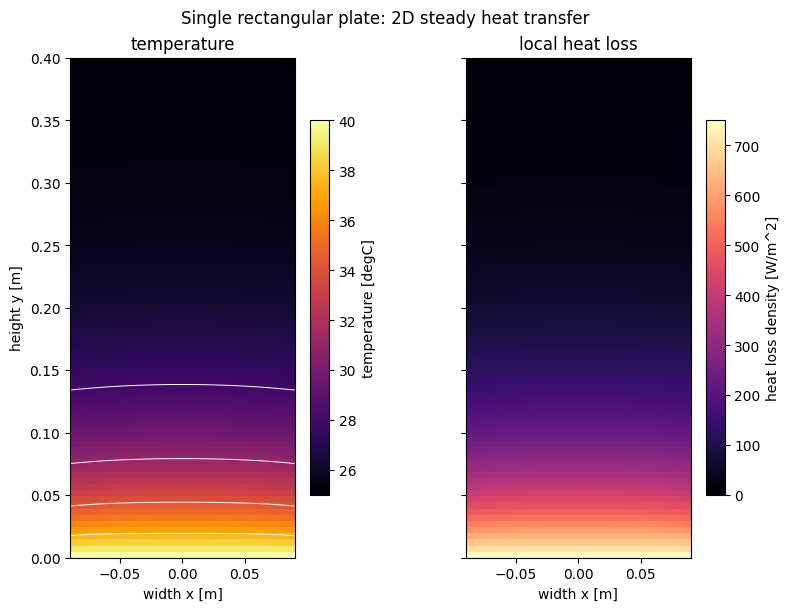

In [3]:
x, y = result['x'], result['y']
X, Y = np.meshgrid(x, y)
temperature = result['temperature']
flux = result['local_face_flux']
fig, axes = plt.subplots(1, 2, figsize=(8, 6), sharex=True, sharey=True, constrained_layout=True)
im_t = axes[0].imshow(temperature, origin='lower', extent=[x.min(), x.max(), y.min(), y.max()],
                      vmin=T_air, vmax=T_base, cmap='inferno', aspect='equal')
axes[0].contour(X, Y, temperature, levels=[28, 31, 34, 37], colors='white', linewidths=0.7)
im_q = axes[1].imshow(flux, origin='lower', extent=[x.min(), x.max(), y.min(), y.max()],
                      vmin=0.0, vmax=2*h*(T_base-T_air), cmap='magma', aspect='equal')
axes[0].set_title('temperature')
axes[1].set_title('local heat loss')
for ax in axes:
    ax.set_xlabel('width x [m]')
axes[0].set_ylabel('height y [m]')
fig.colorbar(im_t, ax=axes[0], label='temperature [degC]', shrink=0.75)
fig.colorbar(im_q, ax=axes[1], label='heat loss density [W/m^2]', shrink=0.75)
fig.suptitle('Single rectangular plate: 2D steady heat transfer')
output = Path('../assets/figures/02_single_plate_temperature.png')
fig.savefig(output, dpi=180, bbox_inches='tight')
plt.show()

## 4. 格子幅を変えて収束を確認する

In [4]:
rows = []
for dx_try in [0.010, 0.005, 0.0025]:
    r = solve_rectangular_plate(dx=dx_try)
    center_top = r['temperature'][-1, len(r['x']) // 2]
    rows.append([dx_try, r['Q_out'], r['Q_base'], r['balance_error'], center_top])
convergence = pd.DataFrame(rows, columns=['dx [m]', 'Q_out [W]', 'Q_base [W]', 'balance error', 'tip T [degC]'])
convergence

,dx [m],Q_out [W],Q_base [W],balance error,tip T [degC]
0,0.0100,14.196828,14.196828,1.473955e-13,25.240693
1,0.0050,13.438953,13.438953,1.587743e-12,25.244926
2,0.0025,13.071459,13.071459,6.094928e-12,25.247249


## 5. 対流係数だけを変える

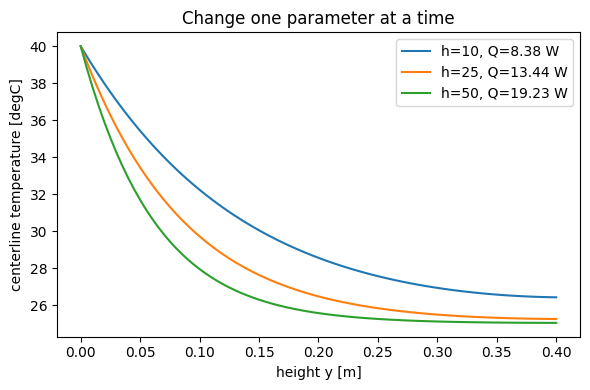

In [5]:
fig, ax = plt.subplots(figsize=(6, 4))
for h_try in [10.0, 25.0, 50.0]:
    r = solve_rectangular_plate(dx=0.005, h_value=h_try)
    centerline = r['temperature'][:, len(r['x']) // 2]
    ax.plot(r['y'], centerline, label=f'h={h_try:g}, Q={r["Q_out"]:.2f} W')
ax.set(xlabel='height y [m]', ylabel='centerline temperature [degC]', title='Change one parameter at a time')
ax.legend()
plt.tight_layout()
plt.show()

## 6. 課題

1. `k`, `h`, `thickness` のうち1つだけを変え、計算前の予想と結果を記録する。
2. 格子幅による `Q_out` の相対変化を計算し、どの格子を以後の基準にするか決める。
3. 根元の一部だけを固定温度にするには、どの条件分岐を変えるべきか説明する。
4. 卒研用Notebookを別名で作り、最初に追加する形状を言葉と数式で定義する。ここではまだ複数形状の比較結果を作らない。